In [30]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

##### Pada cell ini, dilakukan proses loading data dari berbagai sumber file Excel:



##### - **X1**: Persentase kepala keluarga berstatus cerai hidup per kecamatan
##### - **X2**: Persentase keluarga miskin
##### - **X3**: Persentase kepala keluarga perempuan
##### - **X4**: Persentase kepala keluarga dengan pendidikan tidak/belum tamat SD
##### - **X5**: Persentase kepala keluarga perempuan yang bekerja
##### - **X6**: Persentase perempuan berpendidikan SMA ke atas

#### Data diperoleh dari folder `D:\KULIAH\Project\WomanGuard\Data\` dan disimpan dalam variabel `raw_x1` hingga `raw_x6`.


In [31]:
#LOAD DATA

home_path_x1 = "D:\KULIAH\Project\WomanGuard\Data\(X1) Persentase kepala keluarga berstatus cerai hidup per kecamatan"
home_path_x2 = "D:\KULIAH\Project\WomanGuard\Data\(X2) Persentase keluarga miskin"
home_path_x3 = "D:\KULIAH\Project\WomanGuard\Data\(X3) Persentase kepala keluarga perempuan"
home_path_x4 = "D:\KULIAH\Project\WomanGuard\Data\(X4) Persentase kepala keluarga dengan pendidikan tidakbelum tamat SD"
home_path_x5 = "D:\KULIAH\Project\WomanGuard\Data\(X5) Persentase kepala keluarga perempuan yang bekerja"
home_path_x6 = "D:\KULIAH\Project\WomanGuard\Data\(X6) Persentase perempuan berpendidikan SMA ke atas"

raw_x1 = pd.read_excel(rf"{home_path_x1}\2025 untuk X3 juga.xlsx")
raw_x2_1 = pd.read_excel(rf"{home_path_x2}\keluarga_miskin_2024.xlsx")
raw_x2_2 = pd.read_excel(rf"{home_path_x2}\penduduk_kecamatan.xlsx")
raw_x3 = raw_x1
raw_x4 = pd.read_excel(rf"{home_path_x4}\2025.xlsx")
raw_x5 = pd.read_excel(rf"{home_path_x5}\2025.xlsx")
raw_x6 = pd.read_excel(rf"{home_path_x6}\2025.xlsx")

In [32]:
x1 = raw_x1.copy()
x1 = x1.drop(0)
x1 = x1[x1['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)
x1["TOTAL_CERAI_HIDUP"] = x1["CERAI_HIDUP_L"] + x1["CERAI_HIDUP_P"]
x1["PERSENTASE_CERAI_HIDUP"] = (x1["TOTAL_CERAI_HIDUP"] / (x1["BELUM_KAWIN_JUMLAH"] + x1["KAWIN_JUMLAH"] + x1["CERAI_HIDUP_JUMLAH"] + x1["CERAI_MATI_JUMLAH"])) * 100
x1 = x1[["WILAYAH","PERSENTASE_CERAI_HIDUP"]]
x1 = x1.rename(columns={'WILAYAH': 'Kecamatan'})
x1['Kecamatan'] = x1['Kecamatan'].str.lower()
x1

,Kecamatan,PERSENTASE_CERAI_HIDUP
0,karang pilang,7.598383
1,wonocolo,7.080153
2,rungkut,7.038998
3,wonokromo,8.385648
4,tegalsari,8.018005
5,sawahan,8.252222
6,genteng,7.736475
7,gubeng,7.853564
8,sukolilo,7.702233
9,tambaksari,8.076531


In [33]:
x2 = pd.merge(raw_x2_1, raw_x2_2, on="Kecamatan")
x2["Jumlah (KK)"] = pd.to_numeric(x2["Jumlah (KK)"], errors='coerce')
x2["Jumlah KK"] = pd.to_numeric(x2["Jumlah KK"], errors='coerce')
x2["Jumlah (KK)"] = x2["Jumlah (KK)"].fillna(x2["Jumlah (KK)"].median())
x2["Persentase Keluarga Miskin"] = (x2["Jumlah (KK)"] / x2["Jumlah KK"]) * 100
x2 = x2[["Kecamatan", "Persentase Keluarga Miskin"]]
x2['Kecamatan'] = x2['Kecamatan'].str.lower()
x2

,Kecamatan,Persentase Keluarga Miskin
0,asem rowo,1.152213
1,benowo,0.314048
2,bubutan,1.176966
3,bulak,0.843659
4,dukuh pakis,3.133529
5,gayungan,0.818913
6,genteng,2.186382
7,gubeng,1.521610
8,gunung anyar,0.317854
9,jambangan,4.153355


In [34]:
x3 = raw_x3.copy()
x3 = x3.drop(0)
x3 = x3[x3['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)
x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"] = x3["KAWIN_P"] + x3["CERAI_HIDUP_P"] + x3["CERAI_MATI_P"]
x3["TOTAL_KEPALA_KELUARGA"] = x3["KAWIN_JUMLAH"] + x3["CERAI_HIDUP_JUMLAH"] + x3["CERAI_MATI_JUMLAH"]
x3["PERSENTASE_KEPALA_KELUARGA_PEREMPUAN"] = (x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"] / x3["TOTAL_KEPALA_KELUARGA"]) * 100
x3 = x3.rename(columns={'WILAYAH': 'Kecamatan'})
x3['Kecamatan'] = x3['Kecamatan'].str.lower()
x3

,KECAMATAN/KELURAHAN,Kecamatan,BELUM_KAWIN_L,BELUM_KAWIN_P,BELUM_KAWIN_JUMLAH,KAWIN_L,KAWIN_P,KAWIN_JUMLAH,CERAI_HIDUP_L,CERAI_HIDUP_P,CERAI_HIDUP_JUMLAH,CERAI_MATI_L,CERAI_MATI_P,CERAI_MATI_JUMLAH,TOTAL_KEPALA_KELUARGA_PEREMPUAN,TOTAL_KEPALA_KELUARGA,PERSENTASE_KEPALA_KELUARGA_PEREMPUAN
0,KECAMATAN,karang pilang,696,532,1228,16820,680,17500,772,1126,1898,1041,3312,4353,5118,23751,21.548566
1,KECAMATAN,wonocolo,825,652,1477,17163,892,18055,773,1082,1855,1091,3722,4813,5696,24723,23.039275
2,KECAMATAN,rungkut,1095,974,2069,27849,1235,29084,1121,1711,2832,1430,4818,6248,7764,38164,20.343779
3,KECAMATAN,wonokromo,2142,1782,3924,31557,2084,33641,1789,2579,4368,2226,7930,10156,12593,48165,26.145541
4,KECAMATAN,tegalsari,1789,1555,3344,19156,1409,20565,1169,1503,2672,1509,5235,6744,8147,29981,27.173877
5,KECAMATAN,sawahan,2991,2404,5395,39675,2972,42647,2312,3165,5477,3011,9840,12851,15977,60975,26.202542
6,KECAMATAN,genteng,1209,1195,2404,11324,1040,12364,671,892,1563,855,3017,3872,4949,17799,27.804933
7,KECAMATAN,gubeng,1878,1855,3733,27650,1735,29385,1506,2083,3589,1972,7020,8992,10838,41966,25.825668
8,KECAMATAN,sukolilo,1312,1166,2478,25375,1417,26792,1142,1783,2925,1317,4464,5781,7664,35498,21.589949
9,KECAMATAN,tambaksari,2900,2668,5568,47791,3147,50938,2618,3562,6180,3234,10598,13832,17307,70950,24.393235


In [35]:
x4 = raw_x4.copy()
x4 = x4.drop(0)
x4 = x4[x4['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)

# Hitung total kepala keluarga dengan pendidikan tidak/belum tamat SD
x4["TOTAL_TIDAK_BELUM_TAMAT_SD"] = x4["'BELUM TAMAT SD/SEDERAJAT'_L"] + x4["'BELUM TAMAT SD/SEDERAJAT'_P"]

# Hitung total semua kepala keluarga (semua tingkat pendidikan)
x4["TOTAL_KEPALA_KELUARGA"] = (
    x4["'TIDAK/BELUM SEKOLAH'_L"] + x4["'TIDAK/BELUM SEKOLAH'_P"] +
    x4["'BELUM TAMAT SD/SEDERAJAT'_L"] + x4["'BELUM TAMAT SD/SEDERAJAT'_P"] +
    x4["'TAMAT SD/SEDERAJAT'_L"] + x4["'TAMAT SD/SEDERAJAT'_P"] +
    x4["'SLTP/SEDERAJAT'_L"] + x4["'SLTP/SEDERAJAT'_P"] +
    x4["'SLTA/SEDERAJAT'_L"] + x4["'SLTA/SEDERAJAT'_P"] +
    x4["'DIPLOMA I/II'_L"] + x4["'DIPLOMA I/II'_P"] +
    x4["'AKADEMI/DIPLOMA III/S.MUDA'_L"] + x4["'AKADEMI/DIPLOMA III/S.MUDA'_P"] +
    x4["'DIPLOMA IV/STRATA I'_L"] + x4["'DIPLOMA IV/STRATA I'_P"] +
    x4["'STRATA II'_L"] + x4["'STRATA II'_P"] +
    x4["'STRATA III'_L"] + x4["'STRATA III'_P"]
)

# Hitung persentase
x4["PERSENTASE_TIDAK_BELUM_TAMAT_SD"] = (x4["TOTAL_TIDAK_BELUM_TAMAT_SD"] / x4["TOTAL_KEPALA_KELUARGA"]) * 100

# Pilih kolom yang diperlukan
x4 = x4[["WILAYAH", "PERSENTASE_TIDAK_BELUM_TAMAT_SD"]]
x4 = x4.rename(columns={'WILAYAH': 'Kecamatan'})
x4['Kecamatan'] = x4['Kecamatan'].str.lower()
x4

,Kecamatan,PERSENTASE_TIDAK_BELUM_TAMAT_SD
0,karang pilang,1.096921
1,wonocolo,1.213740
2,rungkut,0.802824
3,wonokromo,0.827430
4,tegalsari,1.224306
5,sawahan,0.929637
6,genteng,1.376033
7,gubeng,0.805269
8,sukolilo,0.887403
9,tambaksari,1.135680


In [36]:
x5 = raw_x5.copy()
x5 = x5[x5['NAMA KECAMATAN'] == 'KECAMATAN'].reset_index(drop=True)

# Ambil kolom nama kecamatan
x5 = x5.rename(columns={'NAMA KELURAHAN': 'Kecamatan'})
x5['Kecamatan'] = x5['Kecamatan'].str.lower()

#Ambil kolom PR
x5_cols = [col for col in x5.columns if col.startswith('Unnamed')]
x5_cols = x5_cols[4:]

#
x5["TOTAL_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] = x5[x5_cols].sum(axis=1)
x5["PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] = (x5["TOTAL_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] / x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"]) * 100
x5 = x5[["Kecamatan", "PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"]]
x5

,Kecamatan,PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA
0,karang pilang,38.686987
1,wonocolo,36.569522
2,rungkut,46.097372
3,wonokromo,40.363694
4,tegalsari,38.897754
5,sawahan,34.480816
6,genteng,41.442716
7,gubeng,44.96217
8,sukolilo,41.805846
9,tambaksari,35.563645


In [37]:
x6 = raw_x6.copy()
x6 = x6.drop(0)

# Calculate total women with SMA and above education (SMA + D1/D2 + D3 + D4/S1 + S2 + S3)
x6_cols = [col for col in x6.columns if col.startswith('Unnamed')]
x6_cols_sma_ke_atas = x6_cols[4:]
# x6_cols_sma_ke_bawah = x6_cols[:4]

for col in x6_cols:
    x6[col] = pd.to_numeric(x6[col], errors='coerce')
x6["Total_Perempuan"] = x6[x6_cols].sum(axis=1)

x6["TOTAL_PEREMPUAN_SMA_KE_ATAS"] = x6[x6_cols_sma_ke_atas].sum(axis=1)


x6["PERSENTASE_PEREMPUAN_SMA_KE_ATAS"] = (x6["TOTAL_PEREMPUAN_SMA_KE_ATAS"] / x6["Total_Perempuan"]) * 100


x6 = x6[["Kecamatan\nDistrict", "PERSENTASE_PEREMPUAN_SMA_KE_ATAS"]]
x6 = x6.rename(columns={'Kecamatan\nDistrict': 'Kecamatan'})
x6['Kecamatan'] = x6['Kecamatan'].str.lower()
x6

,Kecamatan,PERSENTASE_PEREMPUAN_SMA_KE_ATAS
1,karangpilang,49.981681
2,jambangan,53.041922
3,gayungan,54.728917
4,wonocolo,48.304520
5,tenggilis mejoyo,50.220367
6,gunung anyar,51.887062
7,rungkut,51.963399
8,sukolilo,47.194641
9,mulyorejo,50.253626
10,gubeng,51.715737


In [38]:
x3 = x3[["Kecamatan", "PERSENTASE_KEPALA_KELUARGA_PEREMPUAN"]]
df = x1.merge(x2, on="Kecamatan").merge(x3, on="Kecamatan").merge(x4, on="Kecamatan").merge(x5, on="Kecamatan").merge(x6, on="Kecamatan")

In [39]:
df = df.rename(columns={
    'PERSENTASE_CERAI_HIDUP': 'x1',
    'Persentase Keluarga Miskin': 'x2',
    'PERSENTASE_KEPALA_KELUARGA_PEREMPUAN': 'x3',
    'PERSENTASE_TIDAK_BELUM_TAMAT_SD': 'x4',
    'PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA': 'x5',
    'PERSENTASE_PEREMPUAN_SMA_KE_ATAS': 'x6'
})
df

,Kecamatan,x1,x2,x3,x4,x5,x6
0,wonocolo,7.080153,4.050129,23.039275,1.213740,36.569522,48.304520
1,rungkut,7.038998,0.080027,20.343779,0.802824,46.097372,51.963399
2,wonokromo,8.385648,4.534781,26.145541,0.827430,40.363694,48.572925
3,tegalsari,8.018005,6.330063,27.173877,1.224306,38.897754,46.748575
4,sawahan,8.252222,2.896873,26.202542,0.929637,34.480816,40.221222
5,genteng,7.736475,2.186382,27.804933,1.376033,41.442716,43.181818
6,gubeng,7.853564,1.521610,25.825668,0.805269,44.96217,51.715737
7,sukolilo,7.702233,2.521251,21.589949,0.887403,41.805846,47.194641
8,tambaksari,8.076531,2.271171,24.393235,1.135680,35.563645,39.865065
9,simokerto,6.764978,4.983302,27.103074,1.939676,33.079797,31.061817


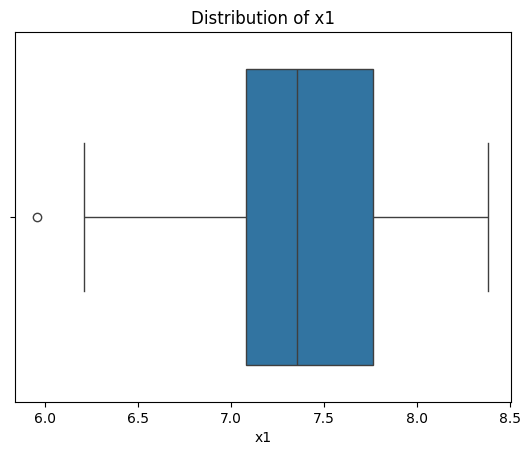

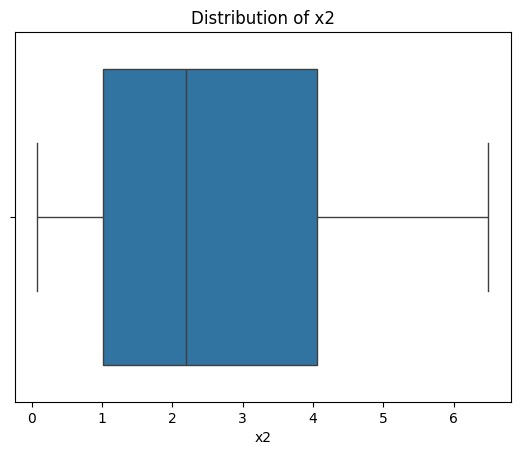

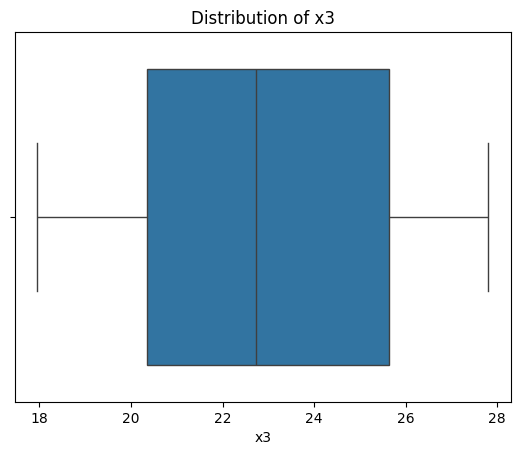

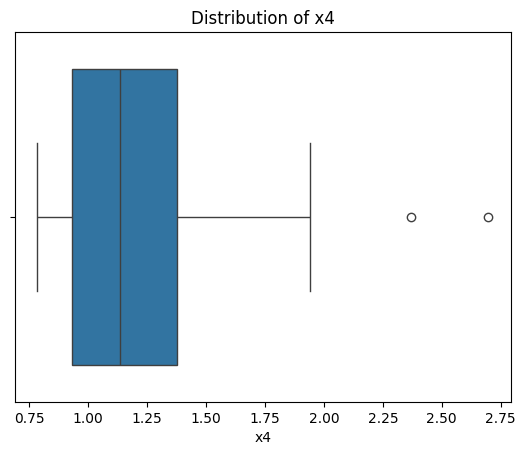

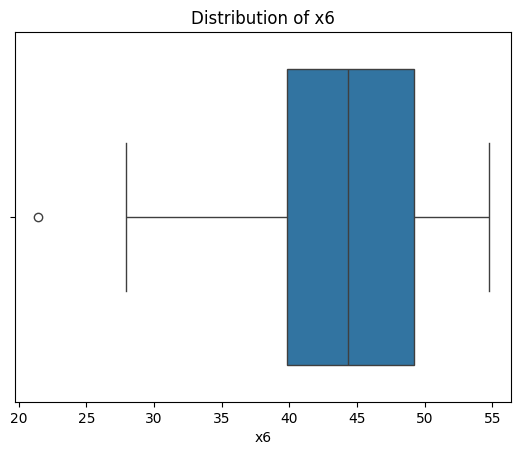

In [40]:
for col in df.select_dtypes(include='number').columns.to_list():
    sns.boxplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [43]:
#Fungsi untuk mengganti outlier dengan Q1 atau Q3
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti outlier
    capped = series.clip(lower=lower_bound, upper=upper_bound)
    return capped

# Terapkan ke semua kolom numerik di df
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    if col != 'Kecamatan':  # Abaikan kolom non-numerik
        df_clean[col] = cap_outliers(df_clean[col])


In [44]:
# Pilih variabel X1 sampai X4
X = df_clean[['x1', 'x2', 'x3', 'x4']]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Tampilkan hasil
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")

# Buat dataframe hasil PCA
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df['Kecamatan'] = df['Kecamatan']
pca_df

Explained Variance Ratio:
[0.46942858 0.38522656 0.11045327 0.03489159]

Total Explained Variance: 1.0000


,PC1,PC2,PC3,PC4,Kecamatan
0,0.321419,0.484655,0.631248,-0.394544,wonocolo
1,-1.801516,-0.729067,-0.165779,-0.506263,rungkut
2,1.902647,-1.751368,0.318087,-0.052688,wonokromo
3,2.654900,-0.324508,0.616785,-0.073771,tegalsari
4,1.348550,-1.553718,-0.423748,0.011430,sawahan
5,1.345668,-0.109476,-1.279005,-0.100567,genteng
6,0.471877,-1.498123,-0.753881,-0.532623,gubeng
7,-0.220029,-1.059111,0.423969,0.092684,sukolilo
8,0.726205,-0.991833,-0.467859,0.466631,tambaksari
9,1.687730,2.451226,-0.265740,-0.296614,simokerto


Woman Guard Index (PC1 + PC2):
           Kecamatan       PC1       PC2  Woman_Guard_Index
9          simokerto  1.687730  2.451226           2.031867
10    pabean cantian  2.366179  1.292313           1.882146
14          semampir  0.525610  3.430687           1.835042
13        krembangan  2.222486  0.427869           1.413582
3          tegalsari  2.654900 -0.324508           1.311964
15          kenjeran -1.193217  3.030492           0.710574
5            genteng  1.345668 -0.109476           0.689778
0           wonocolo  0.321419  0.484655           0.394996
11           bubutan  0.322750  0.254848           0.292144
2          wonokromo  1.902647 -1.751368           0.255639
19       dukuh pakis  0.587878 -0.595651           0.054415
4            sawahan  1.348550 -1.553718           0.040384
25     sukomanunggal -0.627568  0.834151           0.031286
8         tambaksari  0.726205 -0.991833          -0.048182
12            tandes  0.182230 -0.599410          -0.170086
22  tengg

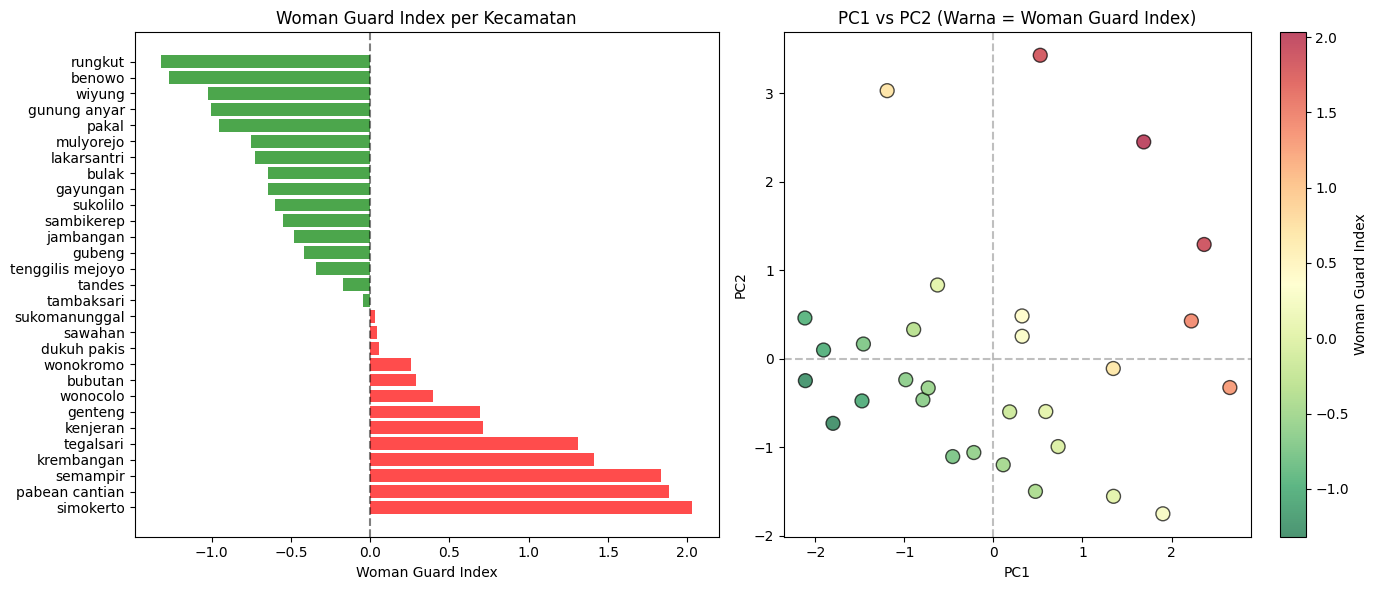


Statistik Woman Guard Index:
Max: 2.0319 (simokerto)
Min: -1.3181 (rungkut)
Mean: 0.0000
Std: 0.9544


In [45]:
# Hitung Woman Guard Index = PC1 + PC2 (komponen dengan variance tertinggi)
w1 = 0.46942858 / (0.46942858 + 0.38522656)
w2 = 0.38522656 / (0.46942858 + 0.38522656)
pca_df['Woman_Guard_Index'] = w1 * pca_df['PC1'] + w2 * pca_df['PC2']

# Tampilkan hasil
print("Woman Guard Index (PC1 + PC2):")
print(pca_df[['Kecamatan', 'PC1', 'PC2', 'Woman_Guard_Index']].sort_values('Woman_Guard_Index', ascending=False))

# Visualisasi
plt.figure(figsize=(14, 6))

# Plot 1: Bar chart Woman Guard Index
plt.subplot(1, 2, 1)
sorted_df = pca_df.sort_values('Woman_Guard_Index', ascending=False)
colors = ['red' if x > 0 else 'green' for x in sorted_df['Woman_Guard_Index']]
plt.barh(sorted_df['Kecamatan'], sorted_df['Woman_Guard_Index'], color=colors, alpha=0.7)
plt.xlabel('Woman Guard Index')
plt.title('Woman Guard Index per Kecamatan')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Plot 2: Scatter PC1 vs PC2 dengan warna berdasarkan WGI
plt.subplot(1, 2, 2)
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Woman_Guard_Index'], 
                      cmap='RdYlGn_r', s=100, alpha=0.7, edgecolors='black')
plt.colorbar(scatter, label='Woman Guard Index')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 (Warna = Woman Guard Index)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("D:/KULIAH/Project/WomanGuard/Plot/Woman_Guard_Index.png", dpi=300)
plt.show()

# Statistik
print(f"\nStatistik Woman Guard Index:")
print(f"Max: {pca_df['Woman_Guard_Index'].max():.4f} ({pca_df.loc[pca_df['Woman_Guard_Index'].idxmax(), 'Kecamatan']})")
print(f"Min: {pca_df['Woman_Guard_Index'].min():.4f} ({pca_df.loc[pca_df['Woman_Guard_Index'].idxmin(), 'Kecamatan']})")
print(f"Mean: {pca_df['Woman_Guard_Index'].mean():.4f}")
print(f"Std: {pca_df['Woman_Guard_Index'].std():.4f}")

K-Means Clustering Results:
           Kecamatan       PC1       PC2  Cluster  Cluster_Label  \
9          simokerto  1.687730  2.451226        2  Rentan Tinggi   
10    pabean cantian  2.366179  1.292313        2  Rentan Tinggi   
14          semampir  0.525610  3.430687        2  Rentan Tinggi   
13        krembangan  2.222486  0.427869        0  Rentan Sedang   
3          tegalsari  2.654900 -0.324508        0  Rentan Sedang   
15          kenjeran -1.193217  3.030492        2  Rentan Tinggi   
5            genteng  1.345668 -0.109476        0  Rentan Sedang   
0           wonocolo  0.321419  0.484655        0  Rentan Sedang   
11           bubutan  0.322750  0.254848        0  Rentan Sedang   
2          wonokromo  1.902647 -1.751368        0  Rentan Sedang   
19       dukuh pakis  0.587878 -0.595651        0  Rentan Sedang   
4            sawahan  1.348550 -1.553718        0  Rentan Sedang   
25     sukomanunggal -0.627568  0.834151        1  Rentan Rendah   
8         tambaksari

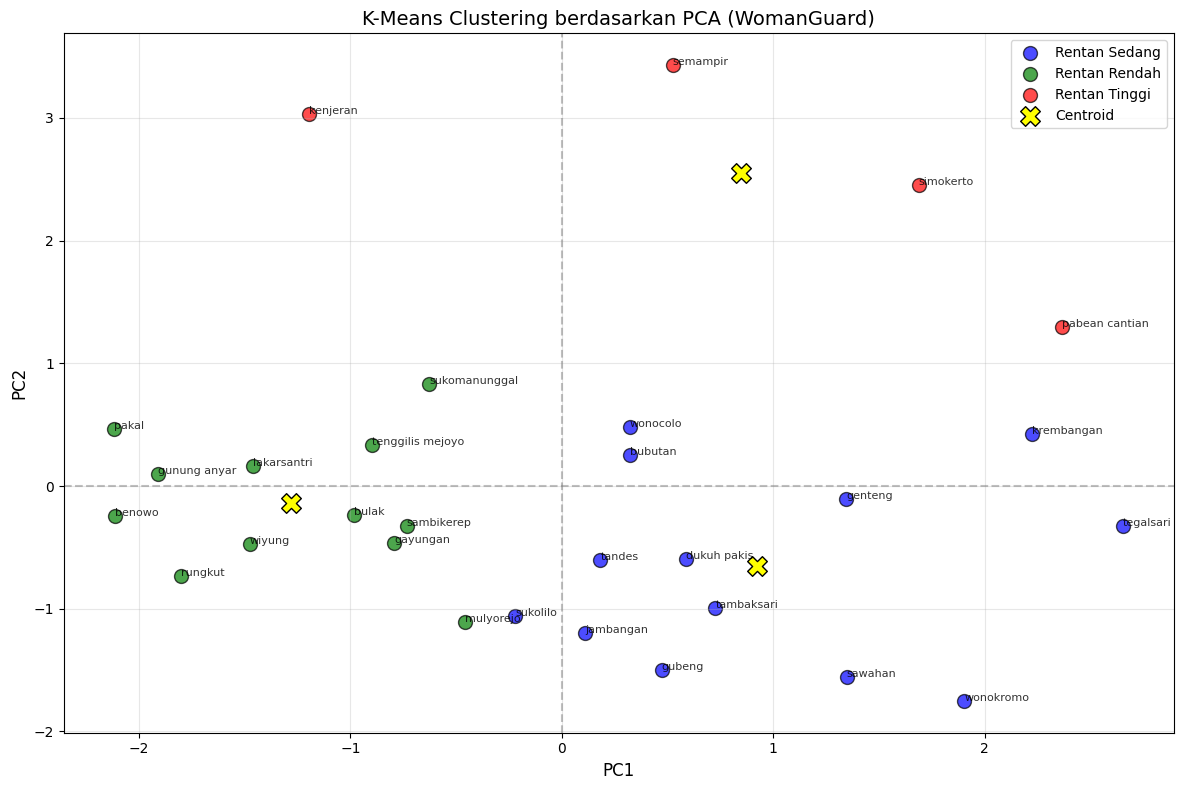


Rata-rata Woman Guard Index per Cluster:
Cluster_Label
Rentan Tinggi    1.614907
Rentan Sedang    0.210838
Rentan Rendah   -0.766711
Name: Woman_Guard_Index, dtype: float64


In [46]:
#Clustering

# Ambil PC1 dan PC2
X_cluster = pca_df[['PC1', 'PC2']]

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(X_cluster)

# Hitung rata-rata Woman Guard Index per cluster
cluster_mean = pca_df.groupby('Cluster')['Woman_Guard_Index'].mean().sort_values(ascending=False)

# Mapping
cluster_mapping = {
    cluster_mean.index[0]: "Rentan Tinggi",
    cluster_mean.index[1]: "Rentan Sedang",
    cluster_mean.index[2]: "Rentan Rendah"
}

# Tambahkan label ke dataframe
pca_df['Cluster_Label'] = pca_df['Cluster'].map(cluster_mapping)

#Output
print("K-Means Clustering Results:")
print(
    pca_df[['Kecamatan', 'PC1', 'PC2', 'Cluster', 'Cluster_Label', 'Woman_Guard_Index']]
    .sort_values('Woman_Guard_Index', ascending=False)
)

#Visual
plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red']

for cluster in range(3):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    label_name = cluster_mapping[cluster]
    
    plt.scatter(
        cluster_data['PC1'], 
        cluster_data['PC2'], 
        c=colors[cluster], 
        s=100, 
        alpha=0.7, 
        label=label_name, 
        edgecolors='black'
    )

# Label kecamatan
for i, row in pca_df.iterrows():
    plt.annotate(row['Kecamatan'], (row['PC1'], row['PC2']), fontsize=8, alpha=0.8)

# Centroid
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    c='yellow', 
    s=200, 
    marker='X', 
    edgecolors='black', 
    label='Centroid'
)

# Styling
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('K-Means Clustering berdasarkan PCA (WomanGuard)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save plot
plt.savefig("D:/KULIAH/Project/WomanGuard/Plot/Clustering_Results.png", dpi=300)

plt.show()

print("\nRata-rata Woman Guard Index per Cluster:")
print(pca_df.groupby('Cluster_Label')['Woman_Guard_Index'].mean().sort_values(ascending=False))

In [75]:
Y = pca_df["Woman_Guard_Index"]
df['x5'] = pd.to_numeric(df['x5'], errors='coerce')
X_pred = df[['x5','x6']]

In [48]:
pca_df.sort_values("Woman_Guard_Index", ascending=False)

,PC1,PC2,PC3,PC4,Kecamatan,Woman_Guard_Index,Cluster,Cluster_Label
9,1.687730,2.451226,-0.265740,-0.296614,simokerto,2.031867,2,Rentan Tinggi
10,2.366179,1.292313,0.240447,-0.082968,pabean cantian,1.882146,2,Rentan Tinggi
14,0.525610,3.430687,0.036885,-0.518314,semampir,1.835042,2,Rentan Tinggi
13,2.222486,0.427869,0.911851,0.291926,krembangan,1.413582,0,Rentan Sedang
3,2.654900,-0.324508,0.616785,-0.073771,tegalsari,1.311964,0,Rentan Sedang
15,-1.193217,3.030492,0.154727,0.616356,kenjeran,0.710574,2,Rentan Tinggi
5,1.345668,-0.109476,-1.279005,-0.100567,genteng,0.689778,0,Rentan Sedang
0,0.321419,0.484655,0.631248,-0.394544,wonocolo,0.394996,0,Rentan Sedang
11,0.322750,0.254848,-1.260881,-0.012318,bubutan,0.292144,0,Rentan Sedang
2,1.902647,-1.751368,0.318087,-0.052688,wonokromo,0.255639,0,Rentan Sedang


In [88]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_pred, Y)

print("=== Linear Regression Results ===")
print(f"Intercept: {reg.intercept_:.6f}")
print(f"Coefficient X5: {reg.coef_[0]:.6f}")
print(f"Coefficient X6: {reg.coef_[1]:.6f}")
print(f"R-squared: {reg.score(X_pred, Y):.6f}")

=== Linear Regression Results ===
Intercept: 3.299637
Coefficient X5: 0.008758
Coefficient X6: -0.083505
R-squared: 0.449011


In [ ]:
df_clean.to_csv(r"D:\KULIAH\Project\WomanGuard\Data\df_cleaned.csv", index=False)

AttributeError: module 'pandas' has no attribute 'to_csv'

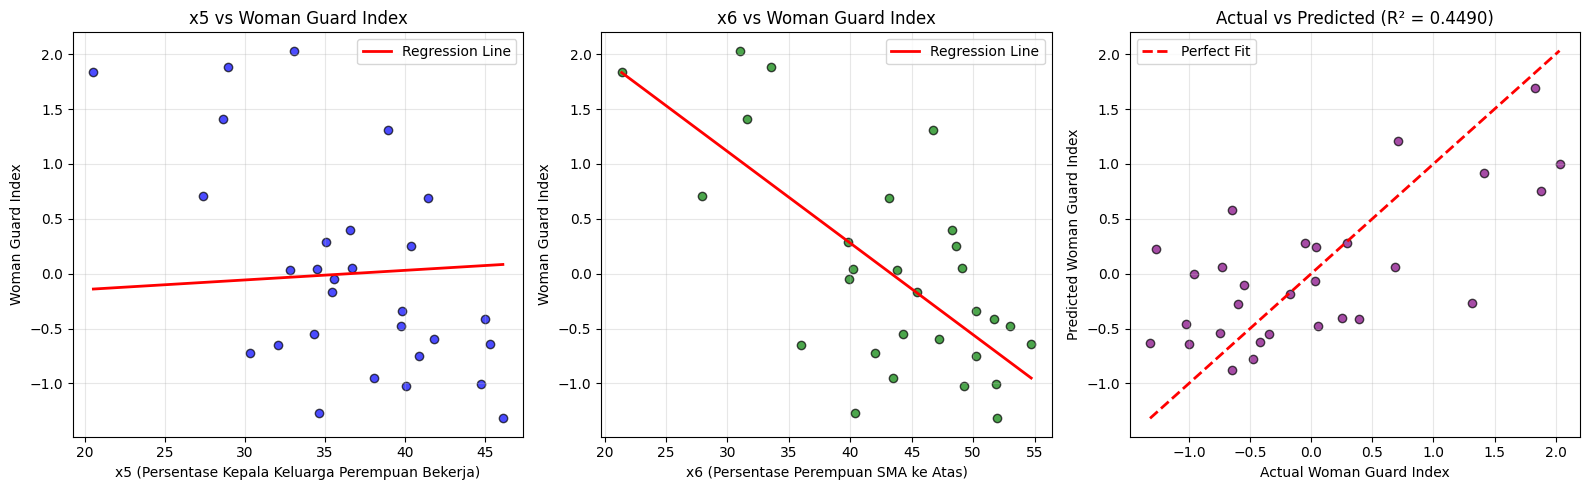


=== Persamaan Regresi ===
Woman_Guard_Index = 3.2996 + (0.0088) × x5 + (-0.0835) × x6


In [89]:
# Visualisasi Regresi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: x5 vs Woman_Guard_Index
axes[0].scatter(df['x5'], Y, color='blue', alpha=0.7, edgecolors='black')
x5_line = np.linspace(df['x5'].min(), df['x5'].max(), 100)
y_pred_line = reg.intercept_ + reg.coef_[0] * x5_line + reg.coef_[1] * df['x6'].mean()
axes[0].plot(x5_line, y_pred_line, color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('x5 (Persentase Kepala Keluarga Perempuan Bekerja)')
axes[0].set_ylabel('Woman Guard Index')
axes[0].set_title('x5 vs Woman Guard Index')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: x6 vs Woman_Guard_Index
axes[1].scatter(df['x6'], Y, color='green', alpha=0.7, edgecolors='black')
x6_line = np.linspace(df['x6'].min(), df['x6'].max(), 100)
y_pred_line2 = reg.intercept_ + reg.coef_[0] * df['x5'].mean() + reg.coef_[1] * x6_line
axes[1].plot(x6_line, y_pred_line2, color='red', linewidth=2, label='Regression Line')
axes[1].set_xlabel('x6 (Persentase Perempuan SMA ke Atas)')
axes[1].set_ylabel('Woman Guard Index')
axes[1].set_title('x6 vs Woman Guard Index')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Actual vs Predicted
Y_pred = reg.predict(X_pred)
axes[2].scatter(Y, Y_pred, color='purple', alpha=0.7, edgecolors='black')
min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[2].set_xlabel('Actual Woman Guard Index')
axes[2].set_ylabel('Predicted Woman Guard Index')
axes[2].set_title(f'Actual vs Predicted (R² = {reg.score(X_pred, Y):.4f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("D:/KULIAH/Project/WomanGuard/Plot/Regression_Visualization.png", dpi=300)
plt.show()

# Tampilkan persamaan regresi
print("\n=== Persamaan Regresi ===")
print(f"Woman_Guard_Index = {reg.intercept_:.4f} + ({reg.coef_[0]:.4f}) × x5 + ({reg.coef_[1]:.4f}) × x6")

=== Perbandingan Woman Guard Index dengan Variabel Asli (x1-x6) ===
       Kecamatan       x1       x2        x3       x4        x5        x6  Woman_Guard_Index Cluster_Label
       simokerto 6.764978 4.983302 27.103074 1.939676 33.079797 31.061817           2.031867 Rentan Tinggi
  pabean cantian 7.386779 6.038996 27.266533 1.670868 28.935532 33.574056           1.882146 Rentan Tinggi
        semampir 5.959580 4.490507 24.648223 2.697586 20.533024 21.397413           1.835042 Rentan Tinggi
      krembangan 7.765830 6.490240 25.305098 1.441657 28.639836 31.562002           1.413582 Rentan Sedang
       tegalsari 8.018005 6.330063 27.173877 1.224306 38.897754 46.748575           1.311964 Rentan Sedang
        kenjeran 6.212524 2.427184 19.407525 2.370360 27.346125 27.940586           0.710574 Rentan Tinggi
         genteng 7.736475 2.186382 27.804933 1.376033 41.442716 43.181818           0.689778 Rentan Sedang
        wonocolo 7.080153 4.050129 23.039275 1.213740 36.569522 48.304520   

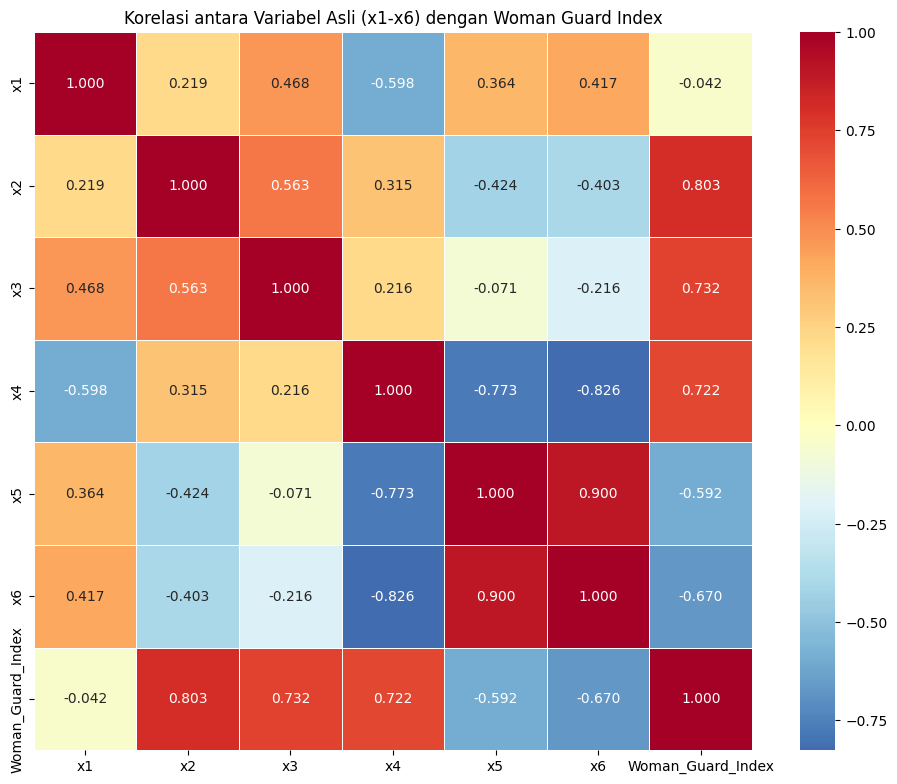


=== Korelasi setiap variabel dengan Woman Guard Index ===
x1: -0.0420
x2: 0.8029
x3: 0.7323
x4: 0.7217
x5: -0.5922
x6: -0.6697


In [90]:
# Gabungkan data asli dengan Woman Guard Index
comparison_df = df.copy()
comparison_df['Woman_Guard_Index'] = pca_df['Woman_Guard_Index'].values
comparison_df['Cluster_Label'] = pca_df['Cluster_Label'].values

# Urutkan berdasarkan Woman Guard Index
comparison_df = comparison_df.sort_values('Woman_Guard_Index', ascending=False)

# Tampilkan tabel perbandingan
print("=== Perbandingan Woman Guard Index dengan Variabel Asli (x1-x6) ===")
print(comparison_df.to_string(index=False))

# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 8))
corr_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'Woman_Guard_Index']
correlation_matrix = comparison_df[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Korelasi antara Variabel Asli (x1-x6) dengan Woman Guard Index', fontsize=12)
plt.tight_layout()
plt.savefig("D:/KULIAH/Project/WomanGuard/Plot/Correlation_Comparison.png", dpi=300)
plt.show()

# Tampilkan korelasi dengan WGI
print("\n=== Korelasi setiap variabel dengan Woman Guard Index ===")
for col in ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']:
    corr = comparison_df[col].corr(comparison_df['Woman_Guard_Index'])
    print(f"{col}: {corr:.4f}")

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Gunakan X_pred (x5 dan x6)
X = X_pred.copy()

# Tambahkan konstanta
X['const'] = 1

# Hitung VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Variable        VIF
0       x5   5.259809
1       x6   5.259809
2    const  40.151418


In [92]:
from sklearn.linear_model import LinearRegression

# Model hanya X6
X6_only = X_pred[['x6']]

reg_x6 = LinearRegression()
reg_x6.fit(X6_only, Y)

print("=== Model hanya X6 ===")
print(f"Intercept: {reg_x6.intercept_:.6f}")
print(f"Coefficient X6: {reg_x6.coef_[0]:.6f}")
print(f"R-squared: {reg_x6.score(X6_only, Y):.6f}")

=== Model hanya X6 ===
Intercept: 3.371525
Coefficient X6: -0.077788
R-squared: 0.448442
